In [1]:
# Run this cell to set up packages for lecture.
from lec14_imports import *

# Lecture 14 – Bootstrapping and Confidence Intervals

## DSC 10, Winter 2026

### Agenda

- Recap: Statistical inference.
- Bootstrapping 🥾.
- Percentiles.
- Confidence intervals.

## Recap: Statistical inference

### City of San Diego employee salary data

All City of San Diego employee salary data [is public](https://publicpay.ca.gov/Reports/Cities/City.aspx?entityid=405&year=2023&rpt=1). We have 2023 salary data for *all* employees, which forms a population.

In [2]:
population = bpd.read_csv('data/2023_salaries.csv')
population

,Year,EmployerType,EmployerName,DepartmentOrSubdivision,...,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType
0,2023,City,San Diego,Police,...,San Diego,NaN,False,NaN
1,2023,City,San Diego,Police,...,San Diego,NaN,False,NaN
2,2023,City,San Diego,Police,...,San Diego,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...
13885,2023,City,San Diego,Transportation,...,San Diego,NaN,False,NaN
13886,2023,City,San Diego,Police,...,San Diego,NaN,False,NaN
13887,2023,City,San Diego,Public Utilities,...,San Diego,NaN,False,NaN


When you load in a dataset that has so many columns that you can't see them all, it's a good idea to look at the column names.

In [3]:
population.columns

Index(['Year', 'EmployerType', 'EmployerName', 'DepartmentOrSubdivision',
       'Position', 'ElectedOfficial', 'Judicial', 'OtherPositions',
       'MinPositionSalary', 'MaxPositionSalary', 'ReportedBaseWage',
       'RegularPay', 'OvertimePay', 'LumpSumPay', 'OtherPay', 'TotalWages',
       'DefinedBenefitPlanContribution', 'EmployeesRetirementCostCovered',
       'DeferredCompensationPlan', 'HealthDentalVision',
       'TotalRetirementAndHealthContribution', 'PensionFormula', 'EmployerURL',
       'EmployerPopulation', 'LastUpdatedDate', 'EmployerCounty',
       'SpecialDistrictActivities', 'IncludesUnfundedLiability',
       'SpecialDistrictType'],
      dtype='object')

We only need the `'TotalWages'` column, so let's `get` just that column.

In [4]:
population = population.get(['TotalWages'])
population

,TotalWages
0,433011
1,416044
2,405315
...,...
13885,10
13886,8
13887,2


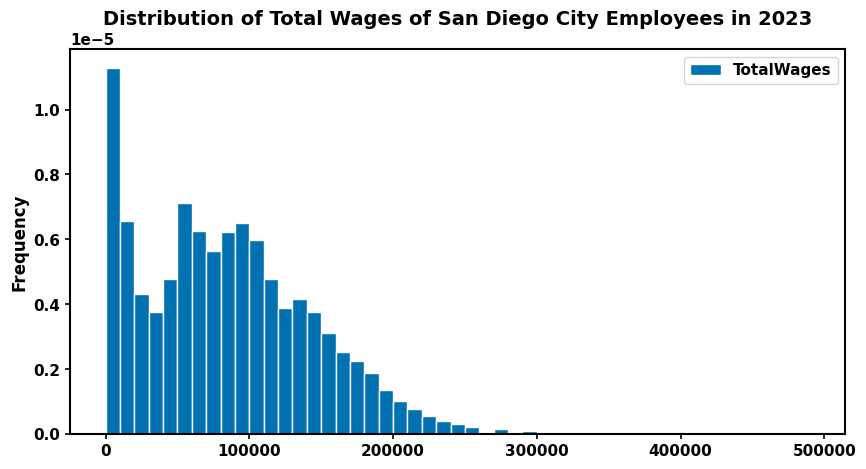

In [5]:
population.plot(kind='hist', bins=np.arange(0, 500000, 10000), density=True, ec='w', figsize=(10, 5),
                title='Distribution of Total Wages of San Diego City Employees in 2023');

### The median salary

- We can use `.median()` to find the median salary of all city employees. 
- This is a **population parameter**.
- This is **not** a random quantity.

In [6]:
population_median = population.get('TotalWages').median()
population_median

np.float64(80492.0)

### Let's be realistic...

- In practice, it is costly and time-consuming to survey **all** the employees.
    - More generally, we can't expect to survey all members of the population we care about.
    - We happen to have the population here, but generally we won't.

- Instead, we gather salaries for a random sample of, say, 500 people.

### Terminology recap

- The full DataFrame of salaries is the **population**.

- We observe a **sample** of 500 salaries from the population.

- We want to determine the **population median (a parameter)**, but we don't have the whole population, so instead we use the **sample median (a statistic) as an estimate**.

- Hopefully the sample median is close to the population median.

### Taking a sample

Let's survey 500 employees at random. To do so, we can use the `.sample` method.

In [7]:
np.random.seed(38) # Magic to ensure that we get the same results every time this code is run.

# Take a sample of size 500 without replacement (for 500 distinct individuals).
my_sample = population.sample(500)
my_sample

,TotalWages
4091,113944
2363,144835
3047,132502
...,...
4338,110628
9238,53840
4798,104600


We won't reassign `my_sample` at any point in this notebook, so it will always refer to this particular sample.

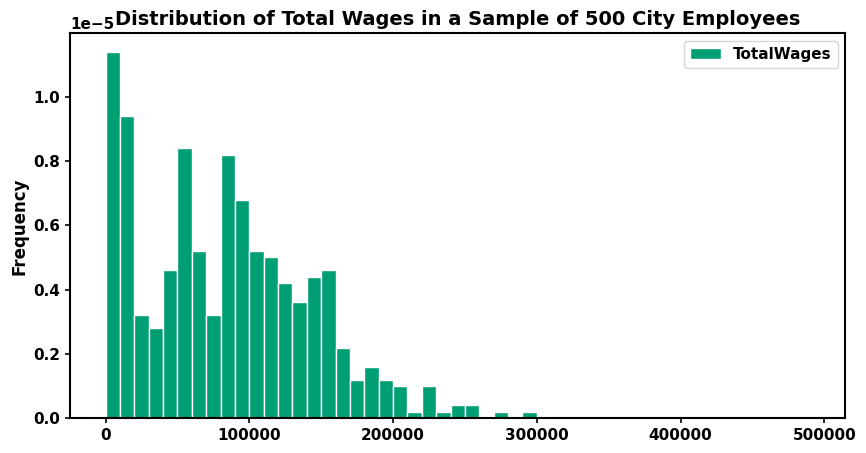

In [8]:
my_sample.plot(kind='hist', bins=np.arange(0, 500000, 10000), density=True, ec='w', figsize=(10, 5),
                color = green, title='Distribution of Total Wages in a Sample of 500 City Employees');

In [9]:
# Compute the sample median.
sample_median = my_sample.get('TotalWages').median()
sample_median

np.float64(82508.0)

### How confident are we that this is a good estimate?

- Our estimate depended on a random sample. If our sample was different, our estimate may have been different, too.

- **How different could our estimate have been?** Our confidence in the estimate depends on the answer to this question.

- The sample median is a random number. It comes from some distribution, which we don't know. 

- If we ***did*** know what the distribution of the sample median looked like, it would help us determine how different our estimate might have been, if we'd drawn a different sample.
    - "Narrow" distribution $\Rightarrow$ not too different.
    - "Wide" distribution $\Rightarrow$ quite different.

### An impractical approach

- One idea: repeatedly collect random samples of 500 **from the population** and compute their medians.
    - This is what we did previously, to compute an empirical distribution of the sample mean of flight delays.

In [10]:
sample_medians = np.array([])
for i in np.arange(1000):
    median = population.sample(500).get('TotalWages').median()
    sample_medians = np.append(sample_medians, median)
sample_medians

array([82603.5, 84498. , 77594.5, ..., 83471.5, 84897.5, 75602. ],
      shape=(1000,))

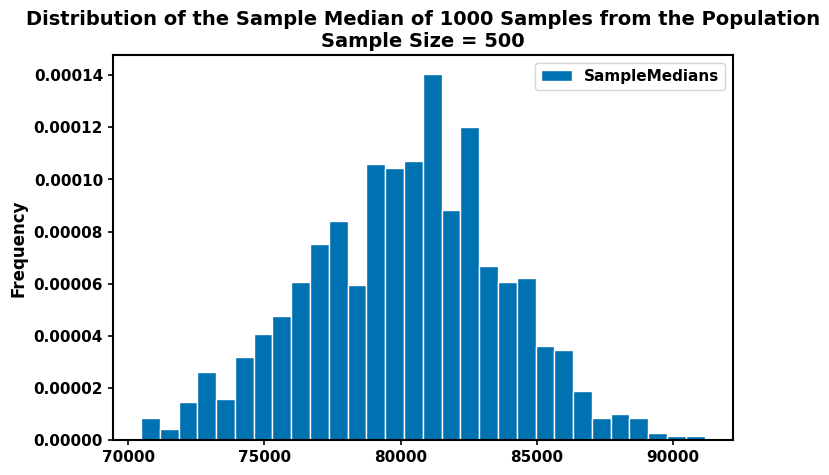

In [11]:
(bpd.DataFrame()
 .assign(SampleMedians=sample_medians)
 .plot(kind='hist', density=True,
       bins=30, ec='w', figsize=(8, 5),
       title='Distribution of the Sample Median of 1000 Samples from the Population\nSample Size = 500')
);

- This shows an empirical distribution of the sample median. It is an approximation of the true probability distribution of the sample median, based on 1000 samples.

### The problem

- Drawing new samples like this is impractical – we usually can't just ask for new samples from the population.
    - If we were able to do this, why not just collect more data in the first place?

- **Key insight**: our original sample, `my_sample`, looks a lot like the population.
    - Their distributions are similar.

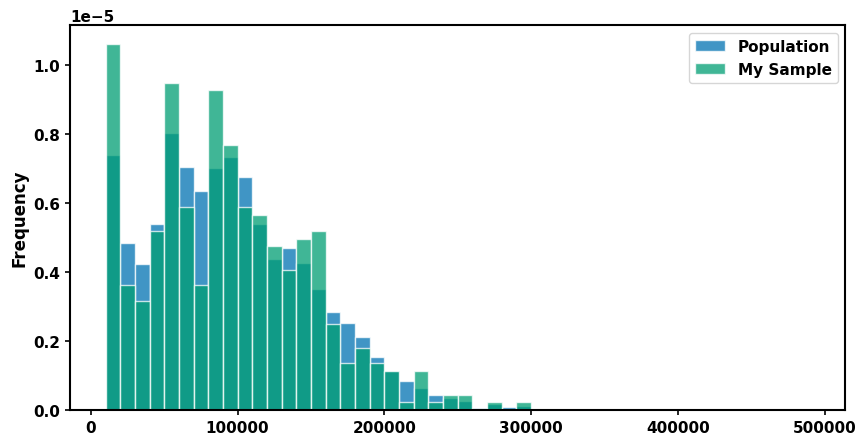

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
bins=np.arange(10_000, 500_000, 10_000)
population.plot(kind='hist', y='TotalWages', ax=ax, density=True, alpha=.75, bins=bins, ec='w')
my_sample.plot(kind='hist', y='TotalWages', ax=ax, density=True, alpha=.75, bins=bins, ec='w')
plt.legend(['Population', 'My Sample']);

Note that unlike the previous histogram we saw, this is depicting the distribution of the population and of one particular sample (`my_sample`), **not** the distribution of sample medians for 1000 samples.

## Bootstrapping 🥾

### Bootstrapping

- **Shortcut**: Use the sample in lieu of the population.
    - The sample itself looks like the population.
    - So, resampling from the sample is kind of like sampling from the population.
    - The act of resampling from a sample is called **bootstrapping**.

- In our case specifically:
    - We have a sample of 500 salaries.
    - We want another sample of 500 salaries, but we can't draw from the population.
    - However, the original sample looks like the population.
    - So, let's just **resample from the sample!**

In [13]:
show_bootstrapping_slides()

### To replace or not replace?

- Our goal when bootstrapping is to create a sample of the same size as our original sample.

- Let's repeatedly resample 3 numbers **without replacement** from an original sample of [7, 9, 4].

In [14]:
original = [7, 9, 4]
for i in np.arange(10):
    resample = np.random.choice(original, 3, replace=False)
    print("Resample: ", resample, "    Median: ", np.median(resample))

Resample:  [9 4 7]     Median:  7.0
Resample:  [7 4 9]     Median:  7.0
Resample:  [4 7 9]     Median:  7.0
Resample:  [4 9 7]     Median:  7.0
Resample:  [7 4 9]     Median:  7.0
Resample:  [9 7 4]     Median:  7.0
Resample:  [4 7 9]     Median:  7.0
Resample:  [7 9 4]     Median:  7.0
Resample:  [9 4 7]     Median:  7.0
Resample:  [4 9 7]     Median:  7.0


- Let's repeatedly resample 3 numbers **with replacement** from an original sample of [7, 9, 4].

In [15]:
original = [7, 9, 4]
for i in np.arange(10):
    resample = np.random.choice(original, 3, replace=True)
    print("Resample: ", resample, "    Median: ", np.median(resample))

Resample:  [7 4 7]     Median:  7.0
Resample:  [9 4 9]     Median:  9.0
Resample:  [9 9 9]     Median:  9.0
Resample:  [9 4 9]     Median:  9.0
Resample:  [4 4 9]     Median:  4.0
Resample:  [9 9 7]     Median:  9.0
Resample:  [4 7 4]     Median:  4.0
Resample:  [9 4 7]     Median:  7.0
Resample:  [4 9 4]     Median:  4.0
Resample:  [7 4 4]     Median:  4.0


- When we resample without replacement, resamples look just like the original samples.

- When we resample with replacement, resamples can have a different mean, median, max, and min than the original sample.

- So, we need to sample **with replacement** to ensure that our resamples can be different from the original sample.

### Bootstrapping the sample of salaries

We can simulate the act of collecting new samples by **sampling with replacement from our original sample, `my_sample`**.

In [16]:
# Note that the population DataFrame, population, doesn't appear anywhere here.
# This is all based on one sample, my_sample.

np.random.seed(38) # Magic to ensure that we get the same results every time this code is run.

n_resamples = 5000
boot_medians = np.array([])

for i in range(n_resamples):
    
    # Resample from my_sample WITH REPLACEMENT.
    resample = my_sample.sample(500, replace=True)
    
    # Compute the median.
    median = resample.get('TotalWages').median()
    
    # Store it in our array of medians.
    boot_medians = np.append(boot_medians, median)

In [17]:
boot_medians

array([85751. , 76009. , 83106. , ..., 82760. , 83470.5, 82711. ],
      shape=(5000,))

### Bootstrap distribution of the sample median

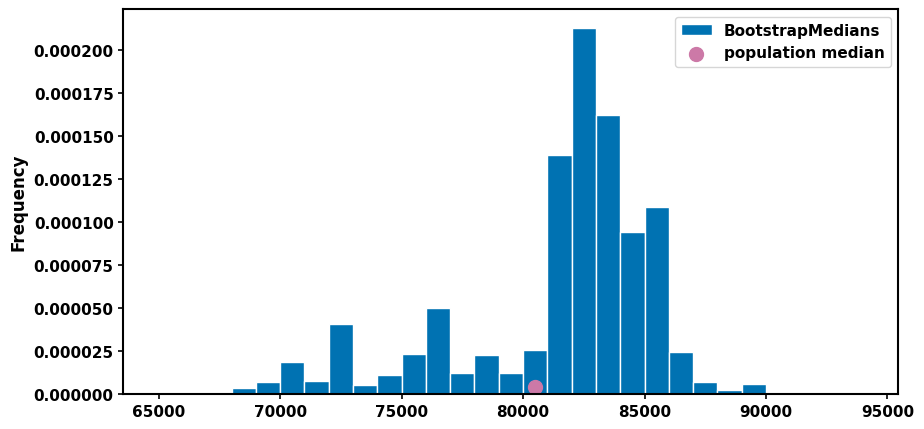

In [18]:
bpd.DataFrame().assign(BootstrapMedians=boot_medians).plot(kind='hist', density=True, bins=np.arange(65000, 95000, 1000), ec='w', figsize=(10, 5))
plt.scatter(population_median, 0.000004, color=pink, s=100, label='population median').set_zorder(2)
plt.legend();

The population median (<b>pink dot</b>) is near the middle.

**In reality, we'd never get to see this!**

### What's the point of bootstrapping?

We have a sample median wage:

In [19]:
my_sample.get('TotalWages').median()

np.float64(82508.0)

With it, we can say that the population median wage is approximately \\$82,508, and not much else.

But by bootstrapping our one sample, we can generate an empirical distribution of the sample median:

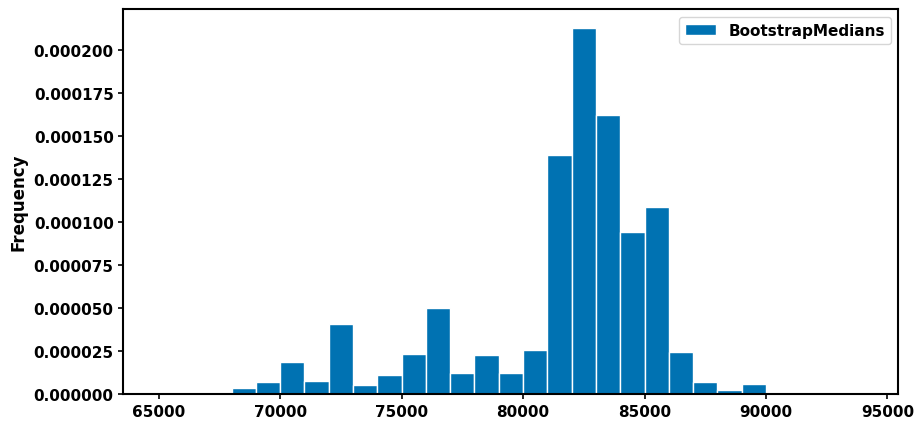

In [20]:
(bpd.DataFrame()
 .assign(BootstrapMedians=boot_medians)
 .plot(kind='hist', density=True, bins=np.arange(65000, 95000, 1000), ec='w', figsize=(10, 5))
)
plt.legend();

which allows us to say things like

> We think the population median wage is between \\$70,000 and \\$88,000.

**Question**: We could also say that we think the population median wage is between \\$80,000 and \\$85,000. What range should we pick?

## Percentiles

### Informal definition

> Let $p$ be a number between 0 and 100. The $p$th percentile of a numerical dataset is a number that's greater than or equal to $p$ percent of all data values. 

<center><img src="images/percentile2.jpg" width=600></center>

**Another example**: If you're in the $80$th percentile for height, it means that roughly $80\%$ of people are shorter than you, and $20\%$ are taller.

<center><img src="images/percentile.svg" width=400></center>

### Calculating percentiles

- The `numpy` package provides a function to calculate percentiles, `np.percentile(array, p)`, which returns the `p`th percentile of `array`. 
- We won't worry about how this value is calculated - we'll just use the result!

In [21]:
np.percentile([4, 6, 9, 2, 7], 50) # unsorted data 

np.float64(6.0)

In [22]:
np.percentile([2, 4, 6, 7, 9], 50) # sorted data

np.float64(6.0)

## Confidence intervals

### Using the bootstrapped distribution of sample medians

Earlier in the lecture, we generated a bootstrapped distribution of sample medians.

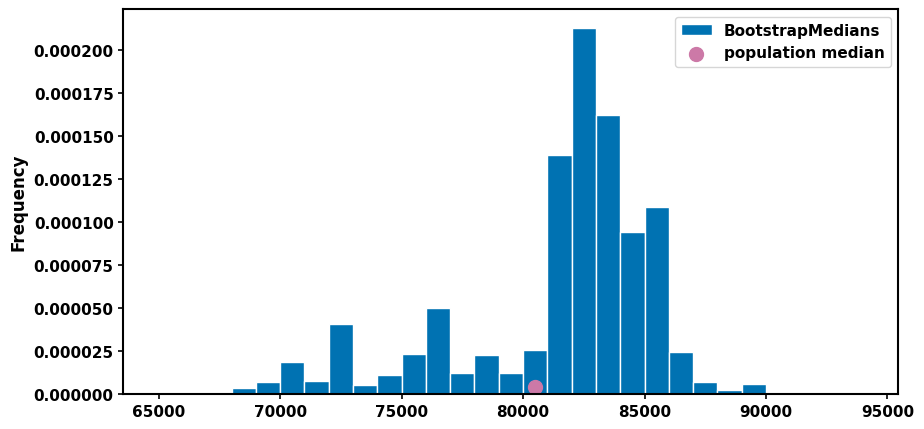

In [23]:
bpd.DataFrame().assign(BootstrapMedians=boot_medians).plot(kind='hist', density=True, bins=np.arange(65000, 95000, 1000), ec='w', figsize=(10, 5))
plt.scatter(population_median, 0.000004, color=pink, s=100, label='population median').set_zorder(2)
plt.legend();

What can we do with this distribution, now that we know about percentiles?

### Using the bootstrapped distribution of sample medians

- We have a sample median, \\$82,508.

- As such, we think the population median is close to \\$82,508. However, we're not quite sure _how_ close.

- How do we capture our uncertainty about this guess?

- 💡 **Idea:** Find a range that captures **most** (e.g. 95%) of the bootstrapped distribution of sample medians. Such an interval is called a **confidence interval**.

### Endpoints of a 95% confidence interval

- We want to find two points, $x$ and $y$, such that:
    - The area to the left of $x$ in the bootstrapped distribution is about 2.5%.
    - The area to the right of $y$ in the bootstrapped distribution is about 2.5%.

- The interval $[x,y]$ will contain about 95% of the total area, i.e. 95% of the total values. As such, we will call $[x, y]$ a **95% confidence interval**.

- $x$ and $y$ are the **2.5th percentile** and **97.5th percentile**, respectively.

### Finding the endpoints with np.percentile

In [24]:
boot_medians

array([85751. , 76009. , 83106. , ..., 82760. , 83470.5, 82711. ],
      shape=(5000,))

In [25]:
# Left endpoint.
left = np.percentile(boot_medians, 2.5)
left

np.float64(70671.5)

In [26]:
# Right endpoint.
right = np.percentile(boot_medians, 97.5)
right

np.float64(86405.0)

In [27]:
# Therefore, our interval is:
[left, right]

[np.float64(70671.5), np.float64(86405.0)]

You will use the code above **very** frequently moving forward!

### Visualizing our 95% confidence interval

- Let's draw the interval we just computed on the histogram.
- 95% of the bootstrap medians fell into this interval.

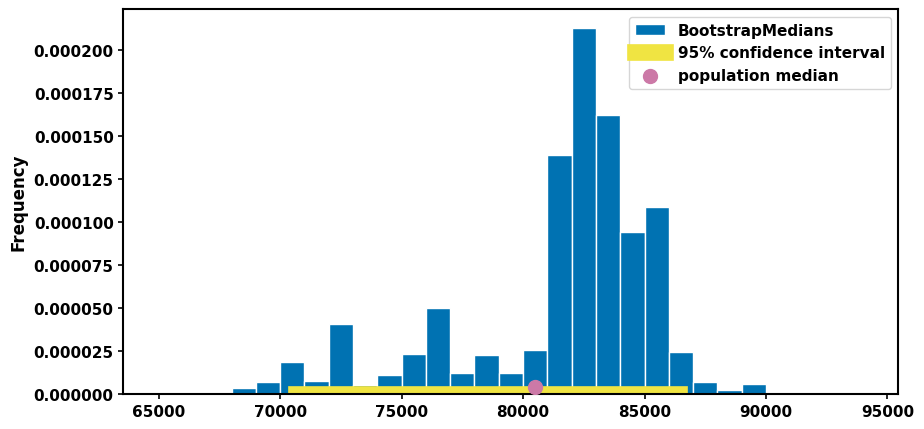

In [28]:
bpd.DataFrame().assign(BootstrapMedians=boot_medians).plot(kind='hist', density=True, bins=np.arange(65000, 95000, 1000), ec='w', figsize=(10, 5), zorder=1)
plt.plot([left, right], [0, 0], color=gold, linewidth=12, label='95% confidence interval', zorder=2);
plt.scatter(population_median, 0.000004, color=pink, s=100, label='population median', zorder=3)
plt.legend();

- In this case, our 95% confidence interval (<b>gold line</b>) contains the true population parameter (<b>pink dot</b>).
    - It won't always, because you might have a bad original sample!
    - In reality, you won't know where the population parameter is, and so you won't know if your confidence interval contains it.

### Concept Check ✅ 

We computed the following 95% confidence interval:

In [29]:
print('Interval:', [left, right])
print('Width:', right - left)

Interval: [np.float64(70671.5), np.float64(86405.0)]
Width: 15733.5


If we instead computed an 80% confidence interval, would it be wider or narrower?

<center>
A. Wider &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; B. Narrower &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; C. Impossible to tell
</center

### Reflection

Now, instead of saying

> We think the population median is close to our sample median, \\$82,508.

We can say:

> A 95% confidence interval for the population median is \\$70,671.50 to \\$86,405.

Some lingering questions: What does 95% confidence mean? What are we confident about? Is this technique always "good"?

## Summary, next time

### Summary

- Given a single sample, we want to estimate some population parameter using just one sample. One sample gives one estimate of the parameter. To get a sense of how much our estimate might have been different with a different sample, we need more samples.
    - In real life, sampling is expensive. **You only get one sample!**
- **Key idea**: The distribution of a sample looks a lot like the distribution of the population it was drawn from. So we can treat it like the population and **resample** from it.
- Each resample yields another estimate of the parameter. Taken together, many estimates give a sense of how much variability exists in our estimates, or how certain we are of any single estimate being accurate.
- Bootstrapping gives us a way to generate the empirical distribution of a sample statistic. From this distribution, we can create a $c$% confidence interval by taking the middle $c$% of values of the bootstrapped distribution.
- Such an interval allows us to **quantify the uncertainty** in our estimate of a population parameter.
    - Instead of providing just a single estimate of a population parameter, e.g. \\$82,508, we can provide a range of estimates, e.g. \\$70,671.50 to \\$86,405.
    - Confidence intervals are used in a variety of fields to capture uncertainty. For instance, political researchers create confidence intervals for the proportion of votes their favorite candidate will receive, given a poll of voters.

### Next time

We will:
- Give more context to what the confidence level of a confidence interval means, and learn how to interpret confidence intervals.
- Identify statistics for which bootstrapping doesn't work well.
- Quantify the spread of a distribution.